# 实验3 复杂网络的度相关性

## 一、实验内容及结果

1. 给定网络 `1e0w300.csv`，计算度同配系数，余平均度 `<knn>(k)`，并画出 `<knn>(k)-k` 图。
2. 编写计算条件概率分布的函数，并画出条件概率分布图。


In [4]:
# 度-度相关性
# 导入库
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import rcParams
import pandas as pd
from collections import Counter

# 设置中文字体，避免绘图时中文乱码
rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
rcParams['axes.unicode_minus'] = False

# 加载数据集
df = pd.read_csv("1e0w300.csv")
G = nx.from_pandas_edgelist(df, 'source', 'target', edge_attr='weight',create_using = nx.Graph())

print("节点的加权度为:", nx.degree(G, weight="weight"))
print("节点的余平均度<knn>i为:", nx.average_neighbor_degree(G, weight="weight"))
print("网络的度同配系数为:", nx.degree_assortativity_coefficient(G, weight="weight"))
print("网络的度皮尔逊相关系数为:", nx.degree_pearson_correlation_coefficient(G, weight="weight"))


节点的加权度为: [('_:1:_:ALA', 7), ('_:2:_:GLU', 16), ('_:301:_:ASN', 19), ('_:3:_:SER', 8), ('_:7:_:ALA', 13), ('_:8:_:ALA', 14), ('_:11:_:GLN', 14), ('_:297:_:LEU', 20), ('_:298:_:ASP', 10), ('_:299:_:ALA', 14), ('_:300:_:LEU', 20), ('_:302:_:GLY', 3), ('_:4:_:THR', 13), ('_:293:_:TYR', 42), ('_:6:_:GLY', 9), ('_:10:_:ALA', 10), ('_:5:_:LEU', 27), ('_:9:_:ALA', 17), ('_:12:_:SER', 8), ('_:13:_:GLY', 7), ('_:36:_:ARG', 14), ('_:37:_:GLU', 35), ('_:282:_:LEU', 24), ('_:283:_:PHE', 36), ('_:289:_:LYS', 32), ('_:290:_:LYS', 25), ('_:292:_:ALA', 10), ('_:294:_:THR', 9), ('_:296:_:VAL', 21), ('_:16:_:PHE', 32), ('_:38:_:PHE', 35), ('_:32:_:SER', 10), ('_:33:_:ILE', 21), ('_:35:_:GLY', 6), ('_:39:_:ASN', 20), ('_:14:_:ARG', 19), ('_:15:_:TYR', 37), ('_:17:_:GLY', 7), ('_:40:_:MET', 35), ('_:263:_:ILE', 24), ('_:265:_:VAL', 18), ('_:18:_:THR', 23), ('_:34:_:ALA', 10), ('_:76:_:LYS', 21), ('_:247:_:TYR', 33), ('_:281:_:LEU', 20), ('_:251:_:THR', 16), ('_:255:_:LEU', 11), ('_:77:_:GLN', 16), ('_:254:

In [58]:
# 网络中加权度为 k 的节点为 v1，v2，···，vi，则加权度为 k 的节点的余平均度为每个节点 vi 的余平均度的和的平均
# 定义求余平均度 <knn>(k) 的函数
def average_nearest_neighbor_degree(G):
    degree_dict = dict(G.degree(weight='weight'))
    k = set([degree_dict[i] for i in G.nodes()])  # 获取所有可能的加权度值并去重
    sorted_k = sorted(k)

    k_nn_k = []
    for ki in sorted_k:
        c = 0
        k_nn_i = 0
        for i in G.nodes():
            if degree_dict[i] == ki:
                k_nn_i += sum(G[i][j].get('weight', 1) * G.degree(j) for j in G.neighbors(i)) / ki
                c += 1
        k_nn_k.append(k_nn_i / c)

    return sorted_k, k_nn_k


x, y = average_nearest_neighbor_degree(G)
print("不同加权度 k 对应的余平均度 <knn>(k) 为:")
for i in range(len(x)):
    print("k = %d, <knn>(k) = %.6f" % (x[i], y[i]))


不同加权度 k 对应的余平均度 <knn>(k) 为:
k = 3, <knn>(k) = 5.666667
k = 4, <knn>(k) = 7.250000
k = 5, <knn>(k) = 5.650000
k = 6, <knn>(k) = 6.012821
k = 7, <knn>(k) = 7.555556
k = 8, <knn>(k) = 7.333333
k = 9, <knn>(k) = 7.401235
k = 10, <knn>(k) = 7.321053
k = 11, <knn>(k) = 8.015152
k = 12, <knn>(k) = 7.568182
k = 13, <knn>(k) = 7.440559
k = 14, <knn>(k) = 7.738095
k = 15, <knn>(k) = 7.651282
k = 16, <knn>(k) = 8.054688
k = 17, <knn>(k) = 8.026738
k = 18, <knn>(k) = 8.101852
k = 19, <knn>(k) = 7.905263
k = 20, <knn>(k) = 8.552778
k = 21, <knn>(k) = 8.214286
k = 22, <knn>(k) = 8.116162
k = 23, <knn>(k) = 8.745342
k = 24, <knn>(k) = 8.583333
k = 25, <knn>(k) = 7.617143
k = 26, <knn>(k) = 9.173077
k = 27, <knn>(k) = 8.296296
k = 28, <knn>(k) = 8.690476
k = 29, <knn>(k) = 8.344828
k = 30, <knn>(k) = 8.658333
k = 31, <knn>(k) = 10.354839
k = 32, <knn>(k) = 9.734375
k = 33, <knn>(k) = 8.959596
k = 34, <knn>(k) = 7.976471
k = 35, <knn>(k) = 8.780952
k = 36, <knn>(k) = 6.935185
k = 37, <knn>(k) = 8.53378

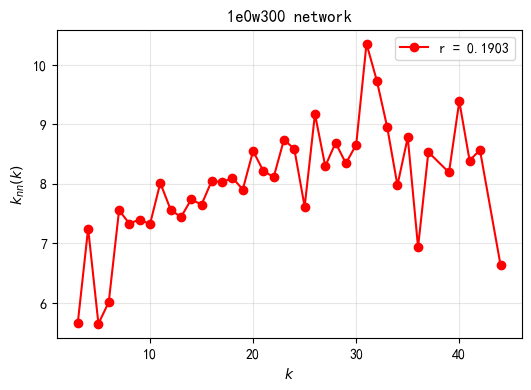

In [8]:
# 绘制 <knn>(k)-k 图
plt.figure(figsize=(6,4))
plt.plot(x, y, 'ro-', label='r = ' + '%.4f' % r)
plt.legend(loc=0)
plt.xlabel("$k$")
plt.ylabel("$k_{nn}(k)$")
plt.title('1e0w300 network')
plt.grid(alpha=0.3)
plt.show()


In [50]:
# 定义条件概率分布 P(k'|k) 的函数
def conditional_probability_distribution(G):
    degree_dict = dict(G.degree(weight='weight'))
    degree_list = sorted(set(degree_dict.values()))
    p_k_prime_k = {}

    for k in degree_list:
        neighbor_degree = []
        for i in G.nodes():
            if degree_dict[i] == k:
                for j in nx.all_neighbors(G, i):
                    neighbor_degree.append(degree_dict[j])

        if len(neighbor_degree) > 0:
            cnt = Counter(neighbor_degree)
            total = len(neighbor_degree)
            p_k_prime_k[k] = {ki: cnt[ki] / total for ki in sorted(cnt.keys())}

    return p_k_prime_k


# 定义度不相关情况下的条件概率分布 q(k') = k'P(k')/<k>
def uncorrelated_distribution(G):
    degree_dict = dict(G.degree(weight='weight'))
    degree_value = list(degree_dict.values())
    cnt = Counter(degree_value)
    n = len(degree_value)
    k_mean = sum(degree_value) / n

    q_k = {}
    for k in sorted(cnt.keys()):
        p_k = cnt[k] / n
        q_k[k] = k * p_k / k_mean

    return q_k


p_k_prime_k = conditional_probability_distribution(G)
q_k = uncorrelated_distribution(G)

# 选取网络中实际存在的几个加权度值作图
selected_k = [10, 16, 24, 35]

for k in selected_k:
    print("k =", k, ", P(k'|k) =", p_k_prime_k[k])


k = 10 , P(k'|k) = {3: 0.019801980198019802, 6: 0.039603960396039604, 7: 0.009900990099009901, 8: 0.009900990099009901, 9: 0.10891089108910891, 10: 0.039603960396039604, 11: 0.0594059405940594, 12: 0.0594059405940594, 13: 0.039603960396039604, 14: 0.0891089108910891, 15: 0.0297029702970297, 16: 0.019801980198019802, 17: 0.0297029702970297, 18: 0.0297029702970297, 19: 0.0297029702970297, 20: 0.04950495049504951, 21: 0.0594059405940594, 22: 0.0297029702970297, 23: 0.039603960396039604, 24: 0.039603960396039604, 25: 0.019801980198019802, 26: 0.009900990099009901, 29: 0.009900990099009901, 33: 0.009900990099009901, 34: 0.009900990099009901, 35: 0.039603960396039604, 36: 0.019801980198019802, 39: 0.019801980198019802, 40: 0.009900990099009901, 42: 0.019801980198019802}
k = 16 , P(k'|k) = {6: 0.023809523809523808, 7: 0.015873015873015872, 8: 0.015873015873015872, 9: 0.007936507936507936, 10: 0.015873015873015872, 11: 0.07142857142857142, 12: 0.047619047619047616, 13: 0.031746031746031744, 14

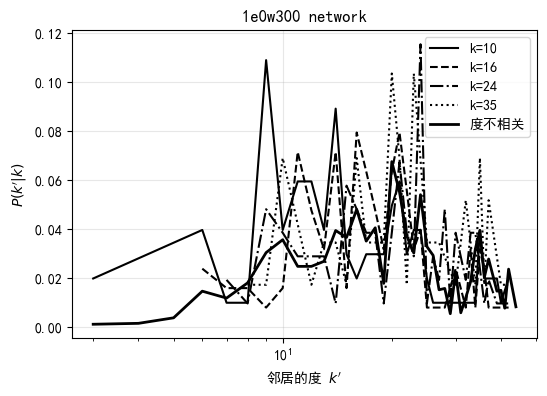

In [52]:
# 绘制条件概率分布图
plt.figure(figsize=(6,4))

line_style = ['k-', 'k--', 'k-.', 'k:']
for i in range(len(selected_k)):
    k = selected_k[i]
    x_k = sorted(p_k_prime_k[k].keys())
    y_k = [p_k_prime_k[k][ki] for ki in x_k]
    plt.plot(x_k, y_k, line_style[i], linewidth=1.5, label='k=' + str(k))

x0 = sorted(q_k.keys())
y0 = [q_k[ki] for ki in x0]
plt.plot(x0, y0, 'k', linewidth=2.0, label='度不相关')

plt.legend(loc=0)
plt.xlabel("邻居的度 $k'$")
plt.ylabel("$P(k'|k)$")
plt.xscale("log")
plt.title('1e0w300 network')
plt.grid(alpha=0.3)
plt.show()
